# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

Answers:
1. The model tries to match the data. Without a limit, it can use huge weights and chase noise. Adding a cost for large weights keeps them smaller so the model doesn't overfit as much.
2. Strong regularization means its a simpler model, making it have less overfitting to one dataset however may miss some real patterns. Weaker regularization provides the opposite. 
3. For ridge, it pulls all coefficients toward zero. They usually stay small, but not zero. LASSO can knock some coefficients down to zero, so some inputs drop out. Thus Ridge keeps all inputs, while LASSO often picks a smaller set. 
4. In regularized regression, we scale so that each input has average 0 and spread of 1. If the scales differ a lot, the penalty hits coefficients in a lopsided way that doesn't match how important the inputs actually are. 
5. Usually they are selected by picking the one with the lowest average error on the left-out data trying different penalty strenghts and using cross-validation. 
6. No, since the penalty is only used while fitting and is part of the training, not the prediction error.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

df = pd.read_csv("./data/cars_hw.csv")
df["Age"] = df["Make_Year"].max() - df["Make_Year"]
X = df[["Mileage_Run", "Age"]]
y = df["Price"]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [ ]:
lr = LinearRegression()
lr.fit(X_scaled, y)
coeffs = pd.Series(lr.coef_, index=feature_names)
print(coeffs)

Mileage_Run          458071.119627
Age                 -136698.072100
Mileage_Run^2        -91643.120024
Mileage_Run Age     -898405.751356
Age^2                113603.822348
Mileage_Run^3        -65144.896599
Mileage_Run^2 Age    229021.676556
Mileage_Run Age^2    368955.713359
Age^3                -84038.066146
dtype: float64


The sign is negative, thus mileage and age together decrease price.

In [ ]:
alphas = np.logspace(1, 3, 20)
lasso = LassoCV(alphas=alphas,cv=20, max_iter=100000)
lasso.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso.coef_,index=feature_names)

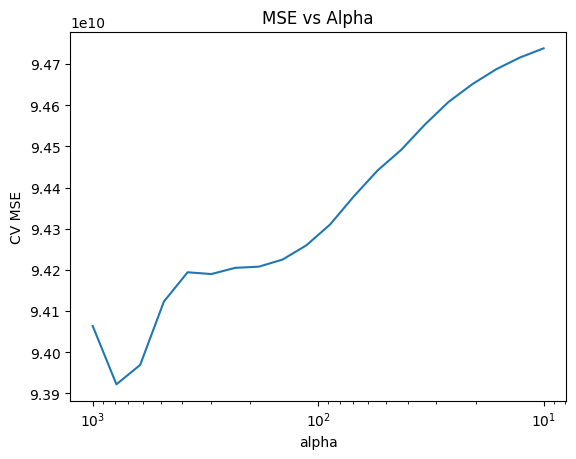

In [ ]:
mean = np.mean(lasso.mse_path_, axis=1)
plt.plot(lasso.alphas_, mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("MSE vs Alpha")
plt.gca().invert_xaxis()
plt.show()

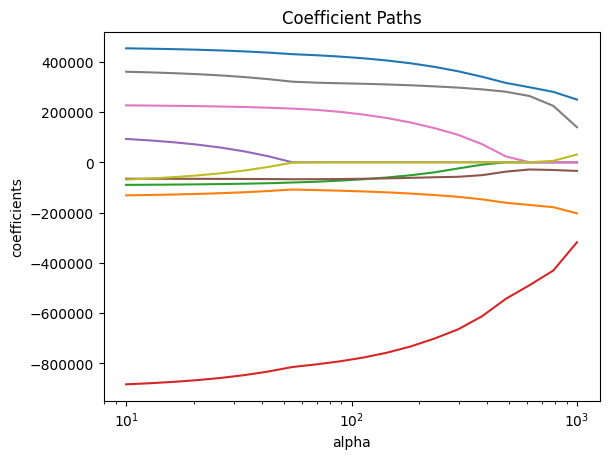

In [ ]:
coefs = []
for x in alphas:
    l = LassoCV(alphas=[x], cv=20,max_iter=100000)
    l.fit(X_scaled,y)
    coefs.append(l.coef_)
coefs = np.array(coefs)
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:,i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Coefficient Paths")
plt.show()

In [ ]:
selected =lasso_coefs[lasso_coefs != 0]
num_zero= np.sum(lasso_coefs ==0)
prop_zero= num_zero / len(lasso_coefs)
print("Selected features:")
print(selected)
print("\nProportion zero:", prop_zero)

Selected features:
Mileage_Run          279901.144475
Age                 -178627.649418
Mileage_Run Age     -430522.371167
Mileage_Run^3        -30772.352392
Mileage_Run Age^2    224381.027339
Age^3                  5666.626835
dtype: float64

Proportion zero: 0.3333333333333333


In [ ]:
compare = pd.DataFrame({
    "Linear": coeffs,
    "Lasso": lasso_coefs
})
print(compare)

                          Linear          Lasso
Mileage_Run        458071.119627  279901.144475
Age               -136698.072100 -178627.649418
Mileage_Run^2      -91643.120024      -0.000000
Mileage_Run Age   -898405.751356 -430522.371167
Age^2              113603.822348      -0.000000
Mileage_Run^3      -65144.896599  -30772.352392
Mileage_Run^2 Age  229021.676556       0.000000
Mileage_Run Age^2  368955.713359  224381.027339
Age^3              -84038.066146    5666.626835


Yes, there is a sign flip and there are coefficients that increase in magnitude. 

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
df =pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
y= df["DEATH_EVENT"]
X_cont = df[["age","ejection_fraction", "serum_creatinine"]]
X_dummy =df[["anaemia","diabetes","high_blood_pressure", "smoking"]]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly =poly_cont.fit_transform(X_cont)
cont_names = poly_cont.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)
poly_dummy = PolynomialFeatures(degree=4, interaction_only=True, include_bias=False)
X_dummy_int = poly_dummy.fit_transform(X_dummy)
dummy_names = poly_dummy.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])

X_all = np.hstack([X_cont_scaled, X_dummy_int])
feature_names = np.concatenate([cont_names, dummy_names])
lr = LinearRegression()
lr.fit(X_all, y)
lr_coefs = pd.Series(lr.coef_, index=feature_names)
print("Linear regression coefficients:")
print(lr_coefs.sort_values(key=np.abs, ascending=False))

Linear regression coefficients:
age^2                                          -3.717758
ejection_fraction^2                             3.352956
serum_creatinine^2                             -2.640240
ejection_fraction serum_creatinine              2.569764
ejection_fraction                              -2.062277
age^3                                           1.963124
age serum_creatinine                            1.707056
age ejection_fraction serum_creatinine         -1.626996
age                                             1.619432
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction serum_creatinine^2            1.189516
ejection_fraction^2 serum_creatinine           -1.151378
age^2 ejection_fraction                         1.054408
age ejection_fraction                          -0.800726
serum_creatinine                               -0.757092
age^2 serum_creatinine                         -0.679042

Some coefficients are counterintuitive such as age being positive, suggesting that higher age decreases the risk of death. This occurs because the model includes higher-order terms and interactions, thus the effect of the variable is determined by the combination of the linear and higher order terms, not by just the coefficient itself. 

In [24]:
alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=200000)
lasso_cv.fit(X_all, y)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
print("Best alpha:", lasso_cv.alpha_)
print("\nLASSO coefficients:")
print(lasso_coefs[lasso_coefs != 0].sort_values(key=np.abs, ascending=False))

KeyboardInterrupt: 

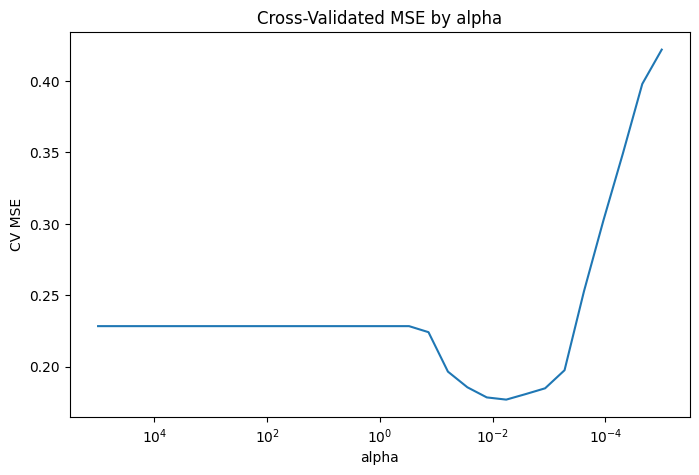

In [ ]:
mean = lasso_cv.mse_path_.mean(axis=1)
plt.figure(figsize=(8,5))
plt.plot(lasso_cv.alphas_, mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("Cross-Validated MSE by alpha")
plt.gca().invert_xaxis()
plt.show()

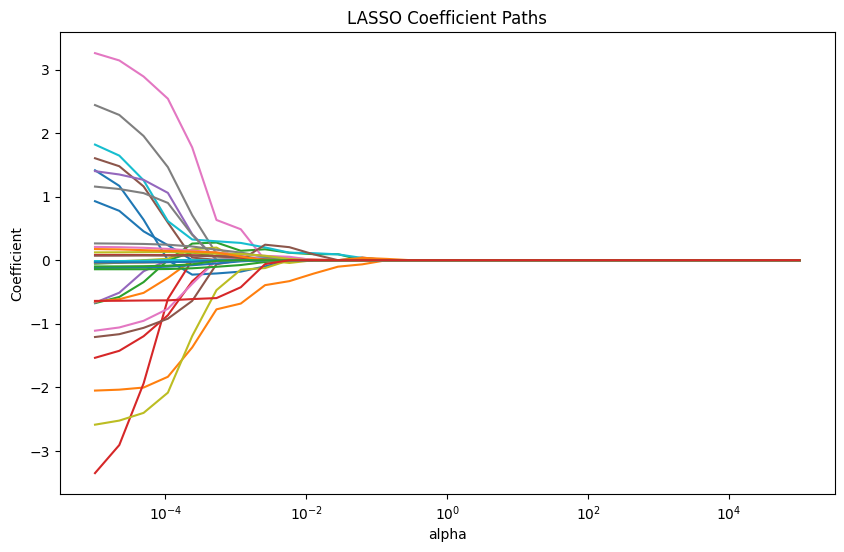

In [ ]:
coef_path = []
for x in alphas:
    model = Lasso(alpha=x, max_iter=200000)
    model.fit(X_all, y)
    coef_path.append(model.coef_)
coef_path = np.array(coef_path)
plt.figure(figsize=(10,6))
for i in range(coef_path.shape[1]):
    plt.plot(alphas, coef_path[:, i], label=feature_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths")
plt.show()

In [ ]:
selected = lasso_coefs[lasso_coefs != 0]
num_zero = (lasso_coefs == 0).sum()
prop_zero = num_zero / len(lasso_coefs)
print("Selected features:")
print(selected)
print("\nNumber set to zero:", num_zero)
print("Proportion set to zero:", prop_zero)

Selected features:
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64

Number set to zero: 22
Proportion set to zero: 0.6470588235294118


In [ ]:
comparison = pd.DataFrame({"Linear": lr_coefs,"Lasso": lasso_coefs})
print(comparison)
increased_mag = comparison[np.abs(comparison["Lasso"]) > np.abs(comparison["Linear"])]
sign_changed = comparison[np.sign(comparison["Linear"]) != np.sign(comparison["Lasso"])]
print("\nIncreased magnitude under LASSO:")
print(increased_mag)
print("\nChanged sign:")
print(sign_changed)

                                                Linear     Lasso
age                                           1.619432 -0.000000
ejection_fraction                            -2.062277 -0.329656
serum_creatinine                             -0.757092  0.116875
age^2                                        -3.717758  0.000000
age ejection_fraction                        -0.800726 -0.000000
age serum_creatinine                          1.707056  0.000000
ejection_fraction^2                           3.352956  0.000000
ejection_fraction serum_creatinine            2.569764  0.000000
serum_creatinine^2                           -2.640240 -0.000000
age^3                                         1.963124  0.117992
age^2 ejection_fraction                       1.054408  0.000000
age^2 serum_creatinine                       -0.679042  0.000000
age ejection_fraction^2                      -0.066433  0.000000
age ejection_fraction serum_creatinine       -1.626996  0.000000
age serum_creatinine^2   

Compared to the normal LR model, most LASSO coefficients are smaller in magnitude but a few slightly increase after correlated variables are removed. Some coefficeints change sign. From a bias-variance trade-off perspective, ordinary least squares has low bias but high variance, leading to overfitting and unstable coefficient estimates. LASSO shows some bias by lowering the coefficients toward zero, but reduces variance. The tradeoff results in a generally better model. 

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?


1. With model $\tilde{y}_i = b_0 + b_1 \tilde{x}_i$, the (mean) squared error plus ridge penalty is
   $\displaystyle J = \frac{1}{n} \sum_{i=1}^{n} \left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right)^2 + \alpha b_1^2.$
2. Derivatives:
   $\displaystyle \frac{\partial J}{\partial b_0} = -\frac{2}{n} \sum_{i=1}^n \left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right) = 0.$
   Because $\sum_i \tilde{x}_i = \sum_i \tilde{y}_i = 0$, setting this to zero gives **$b_0 = 0$** at the optimum.
   $\displaystyle \frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i \left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right) + 2\alpha b_1.$
   Substituting $b_0 = 0$ and solving $\partial J / \partial b_1 = 0$:
   $\displaystyle -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + 2\alpha b_1 = 0$
   $\displaystyle -\frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{1}{n} \sum_{i=1}^n \tilde{x}_i^2 b_1 + \alpha b_1 = 0$
   $\displaystyle b_1\left(\frac{1}{n} \sum_{i=1}^n \tilde{x}_i^2 + \alpha\right) = \frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i$
   $\displaystyle b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}{\sum_{i=1}^n \tilde{x}_i^2 + n\alpha}.$
   (The same $b_1$ follows from the equivalent one-parameter problem omitting $b_0$, since the data are centered.)
3. Increasing $\alpha$ **shrinks** $b_1$ **toward zero** and **monotonically reduces $|b_1|$** (whether $b_1$ is positive or negative).
4. The penalty $|b_1|$ is **not differentiable at $b_1 = 0$**; you use **subgradients** (or split into cases $b_1<0$, $b_1>0$, and $b_1=0$).

  Case 1: if $b_1 < 0$

   $\displaystyle \text{objective function } J = \text{MSE} + \text{penalty} = \frac{1}{n} \sum_{i=1}^{n} \left(\tilde{y}_i - b_1 \tilde{x}_i \right)^2 - \alpha b_1$
   $\displaystyle \frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) - \alpha$
   $\displaystyle -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) - \alpha = 0$
   $\displaystyle b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2}$

   Since we assume $b_1$ is negative, it must be true that
   $\displaystyle \sum_{i=1}^n \tilde{x}_i \tilde{y}_i < -\frac{n\alpha}{2}$

   Case 2: if $b_1 > 0$

   $\displaystyle \text{objective function } J = \text{MSE} + \text{penalty} = \frac{1}{n} \sum_{i=1}^{n} \left(\tilde{y}_i - b_1 \tilde{x}_i \right)^2 + \alpha b_1$
   $\displaystyle \frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + \alpha$
   $\displaystyle -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i (\tilde{y}_i - b_1 \tilde{x}_i) + \alpha = 0$
   $\displaystyle -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{2}{n} \sum_{i=1}^n \tilde{x}_i^2 b_1 + \alpha = 0$
   $\displaystyle b_1(\frac{2}{n} \sum_{i=1}^n \tilde{x}_i^2) = \frac{2}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i - \alpha$
   $\displaystyle b_1 = \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i - \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2}$

   Since we assume $b_1$ is positive, it must be true that
   $\displaystyle \sum_{i=1}^n \tilde{x}_i \tilde{y}_i > \frac{n\alpha}{2}$


   Case 3:
   
   The region
   $\displaystyle -\frac{n\alpha}{2} \leq \sum_{i=1}^n \tilde{x}_i \tilde{y}_i \leq \frac{n\alpha}{2}$
   $\displaystyle |\sum_{i=1}^n \tilde{x}_i \tilde{y}_i| \leq \frac{n\alpha}{2}$
   which makes $b_1 = 0$.

   Results in,

   $\displaystyle b_1 = \left\{\begin{matrix} \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i - \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2} & \sum_{i=1}^n \tilde{x}_i \tilde{y}_i > \frac{n\alpha}{2} \\ 0 & |\sum_{i=1}^n \tilde{x}_i \tilde{y}_i| \leq \frac{n\alpha}{2} \\ \frac{\sum_{i=1}^n \tilde{x}_i \tilde{y}_i + \frac{n\alpha}{2}}{\sum_{i=1}^n \tilde{x}_i^2} & \sum_{i=1}^n \tilde{x}_i \tilde{y}_i < -\frac{n\alpha}{2} \\ \end{matrix}\right.$

